In [3]:
project_root_dir = !git rev-parse --show-toplevel
project_root_dir = project_root_dir[0]

import os
import sys
from collections import defaultdict

from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.join(project_root_dir, 'lib'))

In [16]:
# @launchit.collect
from collections import namedtuple
import itertools
import torch
from torch.distributions import Categorical
from curriculum_utils import *

class Curriculum:
    def __init__(self):
        game_modifs_stem = [
            ['reset_last_life', 'reset_full_igloo', 'reset_bailey_right_at_the_igloo_door', 'reset_temperature_10'], # 160 + 10 for each remaining temp.
            ['reset_last_life', 'reset_full_igloo', 'reset_bailey_very_near_igloo_door', 'reset_temperature_10'],  
            ['reset_last_life', 'reset_full_igloo', 'reset_bailey_near_center', 'reset_temperature_10'],
            ['reset_last_life', 'reset_one_remaining_igloo', 'reset_bailey_near_center', 'reset_temperature_10'],
            ['reset_last_life', 'reset_three_remaining_igloo', 'reset_bailey_near_center', 'reset_temperature_20'],
            ['reset_last_life', 'reset_half_igloo', 'reset_bailey_near_center'],
            ['reset_last_life', 'reset_half_igloo'],
            ['reset_last_life'],
        ]

        self.game_modifs = []

        for i, row in enumerate(game_modifs_stem):
            sbe = SmoothBoxEnergy(lo=0, hi=1, scale=1)
            self.game_modifs.append((sbe, tuple(row)))

    PlanItem = namedtuple('PlanItem', 'game_modifs game_modifs_probs env_game_modifs')
    
    def get_plan_item(self, t, envs_count):
        assert 0 <= t <= 1, t
        energies = torch.tensor(list(map(lambda gm: gm[0].edf(t).item(), self.game_modifs)))
        probs = energies / energies.sum()
        probs_mat = probs.unsqueeze(0)
        probs_mat = probs_mat.expand(envs_count, -1) # make matrix so each env get its distinct 
        game_modifs_inds = Categorical(probs=probs_mat).sample()

        env_game_modifs = {}
        
        for env_ind, game_modifs_ind in enumerate(game_modifs_inds.ravel()):
            env_game_modifs[env_ind] = self.game_modifs[game_modifs_ind][1]

        return Curriculum.PlanItem(
            game_modifs=None,
            game_modifs_probs=probs,
            env_game_modifs=env_game_modifs,
        )

    def get_game_modifs_set(self):
        return set(itertools.chain.from_iterable(map(lambda gm: gm[1], self.game_modifs)))

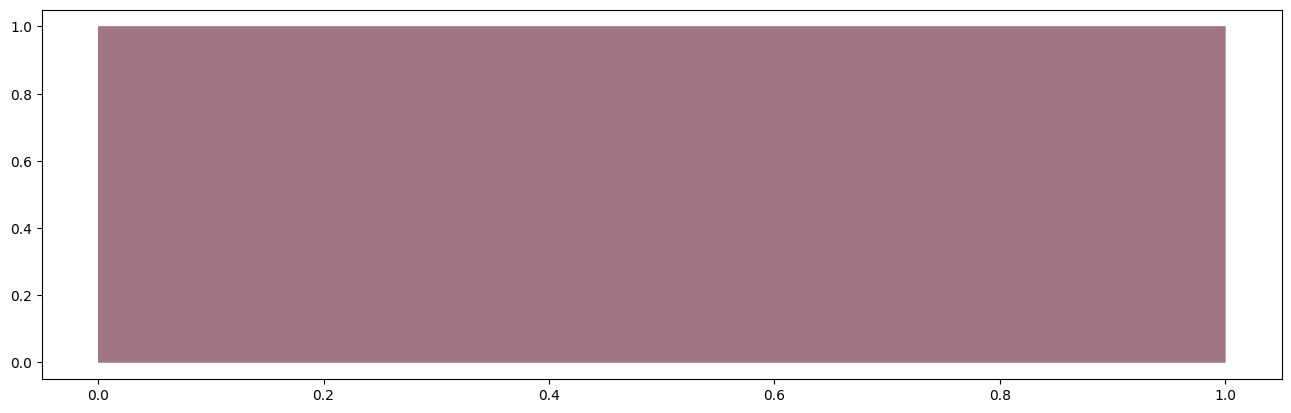

In [17]:
curriculum = Curriculum()

fig, ax = plt.subplots()
fig.set_figwidth(16)
X = np.linspace(0, 1, 1000)

for gm in curriculum.game_modifs:
    Y = gm[0].edf(X)
    plt.fill_between(X, Y, alpha=0.3)